In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.datasets import make_classification

In [6]:
import sklearn.datasets

In [7]:
dir(sklearn.datasets)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_arff_parser',
 '_base',
 '_california_housing',
 '_covtype',
 '_kddcup99',
 '_lfw',
 '_olivetti_faces',
 '_openml',
 '_rcv1',
 '_samples_generator',
 '_species_distributions',
 '_svmlight_format_fast',
 '_svmlight_format_io',
 '_twenty_newsgroups',
 'clear_data_home',
 'dump_svmlight_file',
 'fetch_20newsgroups',
 'fetch_20newsgroups_vectorized',
 'fetch_california_housing',
 'fetch_covtype',
 'fetch_file',
 'fetch_kddcup99',
 'fetch_lfw_pairs',
 'fetch_lfw_people',
 'fetch_olivetti_faces',
 'fetch_openml',
 'fetch_rcv1',
 'fetch_species_distributions',
 'get_data_home',
 'load_breast_cancer',
 'load_diabetes',
 'load_digits',
 'load_files',
 'load_iris',
 'load_linnerud',
 'load_sample_image',
 'load_sample_images',
 'load_svmlight_file',
 'load_svmlight_files',
 'load_wine',
 'make_biclusters',
 'make_blobs',
 'make_checkerboard

In [8]:
?make_classification

Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with replacement from the infor

In [13]:
?pd.DataFrame

Init signature:
pd.DataFrame(
    data=None,
    index: 'Axes | None' = None,
    columns: 'Axes | None' = None,
    dtype: 'Dtype | None' = None,
    copy: 'bool | None' = None,
) -> 'None'
Docstring:     
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. This alignment also
    occurs if data is a Series or a DataFrame itself. Alignment is done on
    Series/DataFrame inputs.

    If data is a list of dicts, column order follows 

0    0.984
1    0.016
Name: proportion, dtype: float64


<Axes: xlabel='varA', ylabel='varB'>

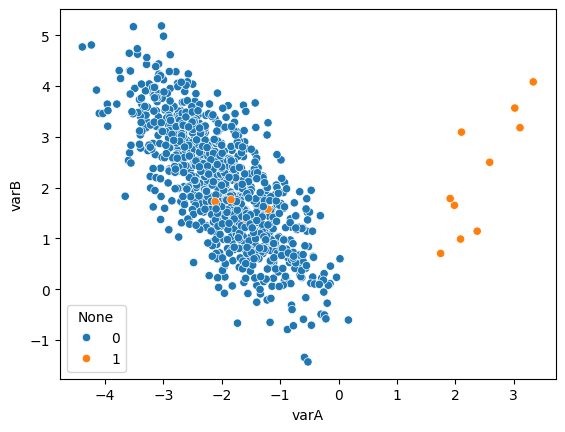

In [34]:
X, y =make_classification(n_samples=1000,
                          n_features=2,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          weights=[0.99],
                          class_sep=2,
                          random_state=0)


X = pd.DataFrame(data=X, columns=['varA', 'varB'])
y = pd.Series(data=y)
print(y.value_counts(normalize=True))
sns.scatterplot(x='varA', y='varB', data=X, hue=y)

In [42]:
def make_data(sep):
    X, y =make_classification(n_samples=1000,
                          n_features=2,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          weights=[0.99],
                          class_sep=sep,
                          random_state=0)


    X = pd.DataFrame(data=X, columns=['varA', 'varB'])
    y = pd.Series(data=y)
    print(y.value_counts(normalize=True))
    # sns.scatterplot(x='varA', y='varB', data=X, hue=y)

    return X, y


0    0.984
1    0.016
Name: proportion, dtype: float64


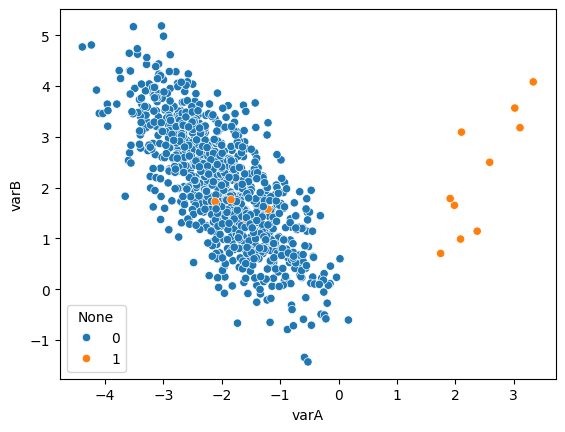

In [41]:
X,y = make_data(2)

0    0.984
1    0.016
Name: proportion, dtype: float64


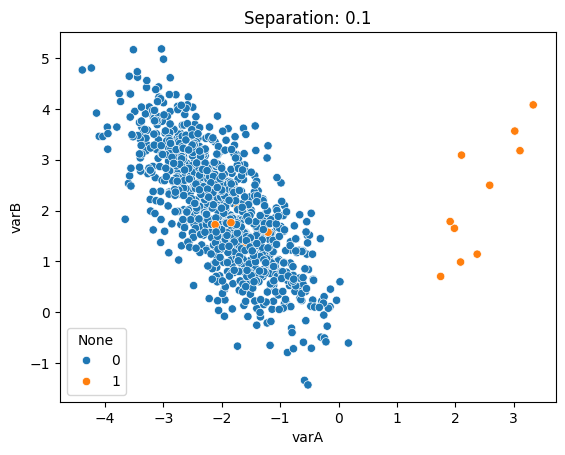

0    0.984
1    0.016
Name: proportion, dtype: float64


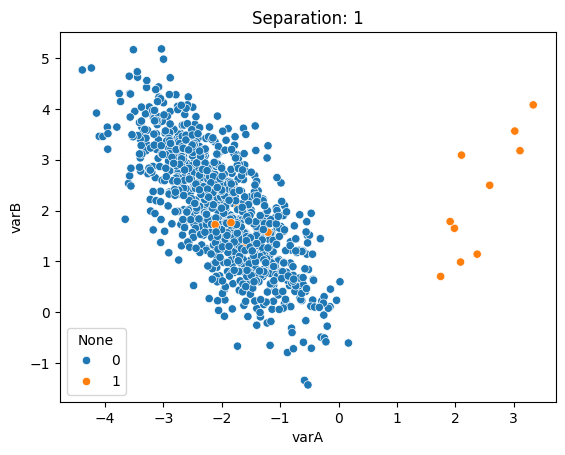

0    0.984
1    0.016
Name: proportion, dtype: float64


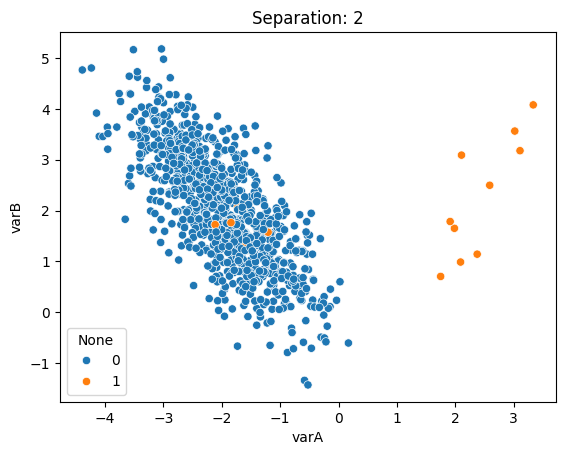

In [44]:
for sep in [0.1, 1, 2]:
    X, y = make_data(2)

    # print(y.value_counts(normalize=True))

    sns.scatterplot(data=X, x='varA', y='varB', hue=y)
    plt.title('Separation: {}'.format(sep))
    plt.show()

# Undersample with Condensed Nearest Neighbours

### Well separate classes

In [45]:
X, y = make_data(sep=2)

0    0.984
1    0.016
Name: proportion, dtype: float64


In [46]:
import imblearn

In [47]:
dir(imblearn)

['FunctionSampler',
 'LazyLoader',
 '__IMBLEARN_SETUP__',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_version',
 'base',
 'combine',
 'ensemble',
 'exceptions',
 'importlib',
 'keras',
 'metrics',
 'over_sampling',
 'pipeline',
 'show_versions',
 'sys',
 'tensorflow',
 'types',
 'under_sampling',
 'utils']

In [49]:
import imblearn.under_sampling

In [50]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [51]:
from imblearn.under_sampling import RandomUnderSampler

In [52]:
help(RandomUnderSampler)

Help on class RandomUnderSampler in module imblearn.under_sampling._prototype_selection._random_under_sampler:

class RandomUnderSampler(imblearn.under_sampling.base.BaseUnderSampler)
 |  RandomUnderSampler(*, sampling_strategy='auto', random_state=None, replacement=False)
 |  
 |  Class to perform random under-sampling.
 |  
 |  Under-sample the majority class(es) by randomly picking samples
 |  with or without replacement.
 |  
 |  Read more in the :ref:`User Guide <controlled_under_sampling>`.
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : float, str, dict, callable, default='auto'
 |      Sampling information to sample the data set.
 |  
 |      - When ``float``, it corresponds to the desired ratio of the number of
 |        samples in the minority class over the number of samples in the
 |        majority class after resampling. Therefore, the ratio is expressed as
 |        :math:`\alpha_{us} = N_{m} / N_{rM}` where :math:`N_{m}` is the
 |        number of samples in 

In [55]:
dir(imblearn.under_sampling)

['AllKNN',
 'ClusterCentroids',
 'CondensedNearestNeighbour',
 'EditedNearestNeighbours',
 'InstanceHardnessThreshold',
 'NearMiss',
 'NeighbourhoodCleaningRule',
 'OneSidedSelection',
 'RandomUnderSampler',
 'RepeatedEditedNearestNeighbours',
 'TomekLinks',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_prototype_generation',
 '_prototype_selection',
 'base']

In [56]:
from imblearn.under_sampling import CondensedNearestNeighbour

In [57]:
help(CondensedNearestNeighbour)

Help on class CondensedNearestNeighbour in module imblearn.under_sampling._prototype_selection._condensed_nearest_neighbour:

class CondensedNearestNeighbour(imblearn.under_sampling.base.BaseCleaningSampler)
 |  CondensedNearestNeighbour(*, sampling_strategy='auto', random_state=None, n_neighbors=None, n_seeds_S=1, n_jobs=None)
 |  
 |  Undersample based on the condensed nearest neighbour method.
 |  
 |  Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : str, list or callable
 |      Sampling information to sample the data set.
 |  
 |      - When ``str``, specify the class targeted by the resampling. Note the
 |        the number of samples will not be equal in each. Possible choices
 |        are:
 |  
 |          ``'majority'``: resample only the majority class;
 |  
 |          ``'not minority'``: resample all classes but the minority class;
 |  
 |          ``'not majority'``: resample all classes but the m

In [58]:
?CondensedNearestNeighbour

Init signature:
CondensedNearestNeighbour(
    *,
    sampling_strategy='auto',
    random_state=None,
    n_neighbors=None,
    n_seeds_S=1,
    n_jobs=None,
)
Docstring:     
Undersample based on the condensed nearest neighbour method.

Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function t

In [54]:
X, y = make_data(sep=2)

#Setting up the condensed nearest neighbor

0    0.984
1    0.016
Name: proportion, dtype: float64


In [62]:
cnn = CondensedNearestNeighbour(
    sampling_strategy='auto',
    random_state=0,
    n_neighbors=1,
    n_jobs=-1
)

X_resampled, y_resampled = cnn.fit_resample(X,y)

In [63]:
#Size of the original data
X.shape, y.shape

((1000, 2), (1000,))

In [64]:
#Size of the undersampled data
X_resampled.shape, y_resampled.shape

((51, 2), (51,))

In [65]:
y.value_counts(normalize=True)

0    0.984
1    0.016
Name: proportion, dtype: float64

In [66]:
y_resampled.value_counts(normalize=True)

0    0.686275
1    0.313725
Name: proportion, dtype: float64

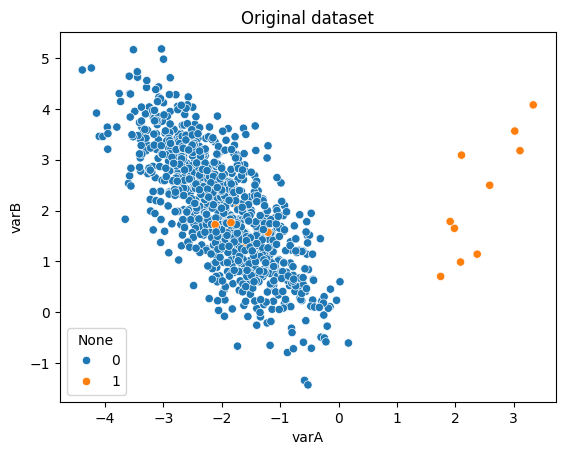

In [68]:
sns.scatterplot(
    x='varA', y='varB', data=X, hue=y
)
plt.title('Original dataset')
plt.show()

<Axes: xlabel='varA', ylabel='varB'>

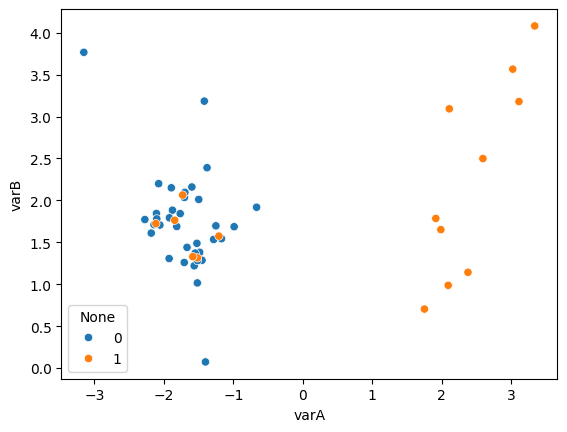

In [69]:
sns.scatterplot(x='varA', y='varB', data=X_resampled, hue=y_resampled)

Text(0.5, 1.0, 'Resampled dataset')

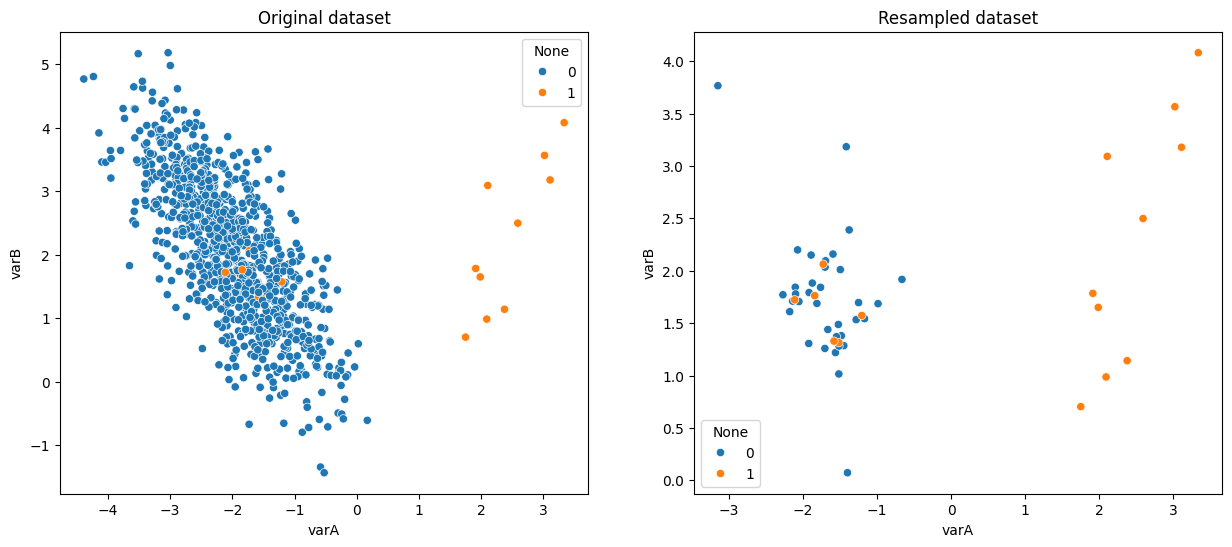

In [74]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)
plt.title('Original dataset')

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled, hue=y_resampled)
plt.title('Resampled dataset')

## Partially separated classes

In [76]:
?CondensedNearestNeighbour

Init signature:
CondensedNearestNeighbour(
    *,
    sampling_strategy='auto',
    random_state=None,
    n_neighbors=None,
    n_seeds_S=1,
    n_jobs=None,
)
Docstring:     
Undersample based on the condensed nearest neighbour method.

Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function t

In [87]:
X, y = make_data(sep=0.1)

cnn = CondensedNearestNeighbour(sampling_strategy='auto',
                                random_state=0,
                                n_neighbors=1,
                                n_jobs=-1)
X_resampled, y_resampled = cnn.fit_resample(X, y)


0    0.984
1    0.016
Name: proportion, dtype: float64


In [88]:
#Original data
X.shape, y.shape

((1000, 2), (1000,))

In [89]:
#Resampled data
X_resampled.shape, y_resampled.shape

((75, 2), (75,))

Text(0.5, 1.0, 'Resampled Dataset')

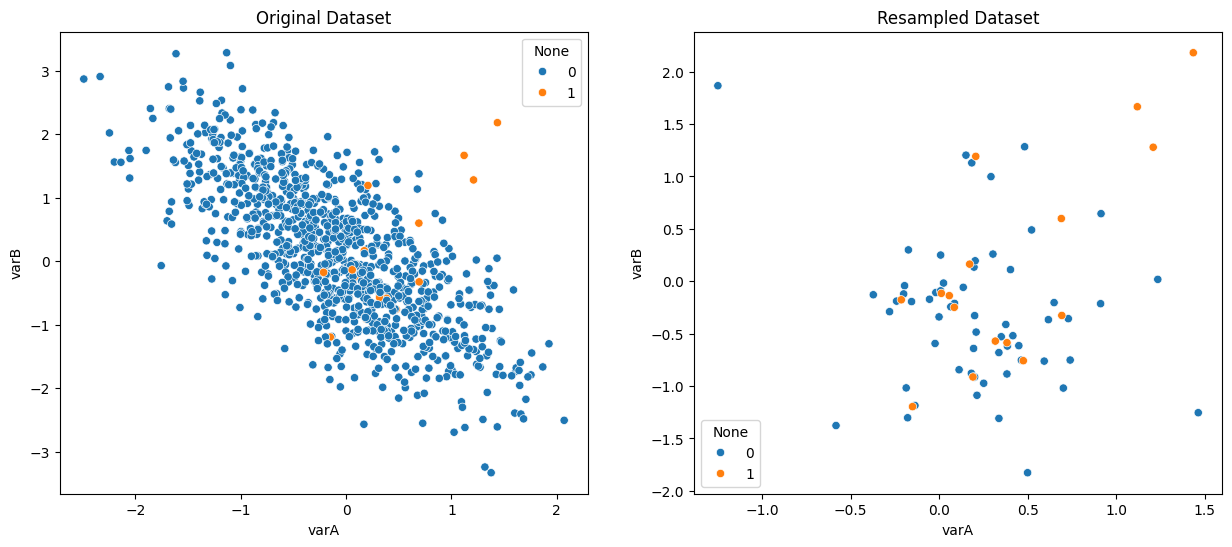

In [90]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)
plt.title('Original Dataset')

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled, hue=y_resampled)
plt.title('Resampled Dataset')

In [91]:
?CondensedNearestNeighbour

Init signature:
CondensedNearestNeighbour(
    *,
    sampling_strategy='auto',
    random_state=None,
    n_neighbors=None,
    n_seeds_S=1,
    n_jobs=None,
)
Docstring:     
Undersample based on the condensed nearest neighbour method.

Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function t

In [92]:
dir(CondensedNearestNeighbour)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_X_y',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_fit_resample',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_sampling_strategy_docstring',
 '_sampling_type',
 '_validate_data',
 '_vali

In [ ]:
X, y = make_data(sep=2)

cnn = CondensedNearestNeighbour(sampling_strategy='auto',
                                random_state=0,
                                n_neighbors=2,
                                n_jobs=-1)

X_resampled, y_resampled = cnn.fit_resample(X, y)

In [93]:
X.shape, y.shape

((1000, 2), (1000,))

In [94]:
X_resampled.shape, y_resampled.shape

((75, 2), (75,))

In [95]:
type(X_resampled), type(y_resampled)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

Text(0.5, 1.0, 'Resampled dataset, KNN(k=2)')

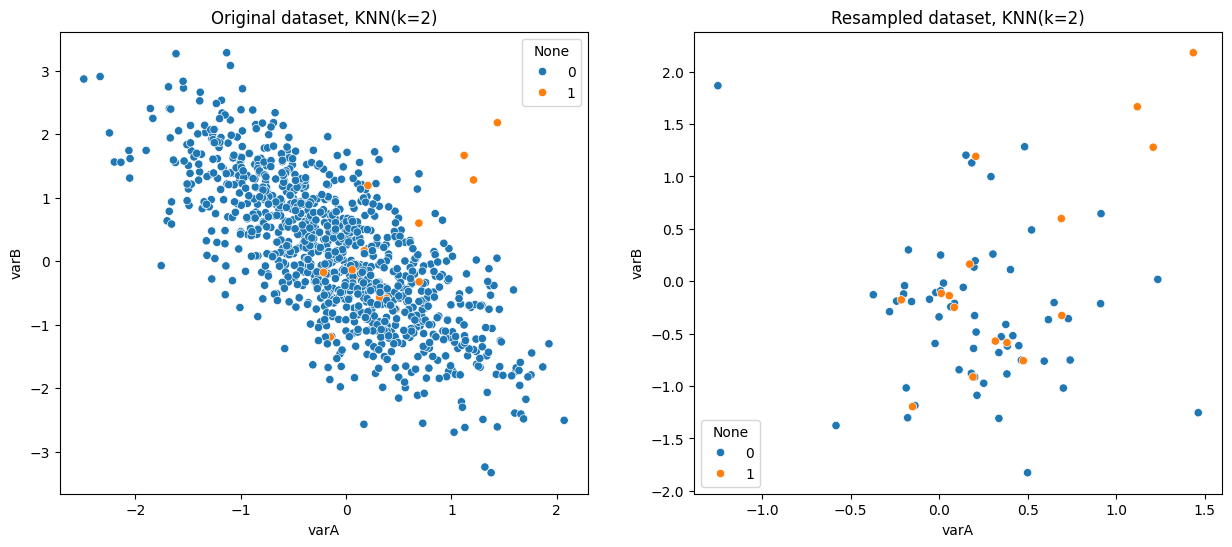

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)
plt.title('Original dataset, KNN(k=2)')

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled, hue=y_resampled)
plt.title('Resampled dataset, KNN(k=2)')

Text(0.5, 1.0, 'Resampled dataset, KNN(k=2)')

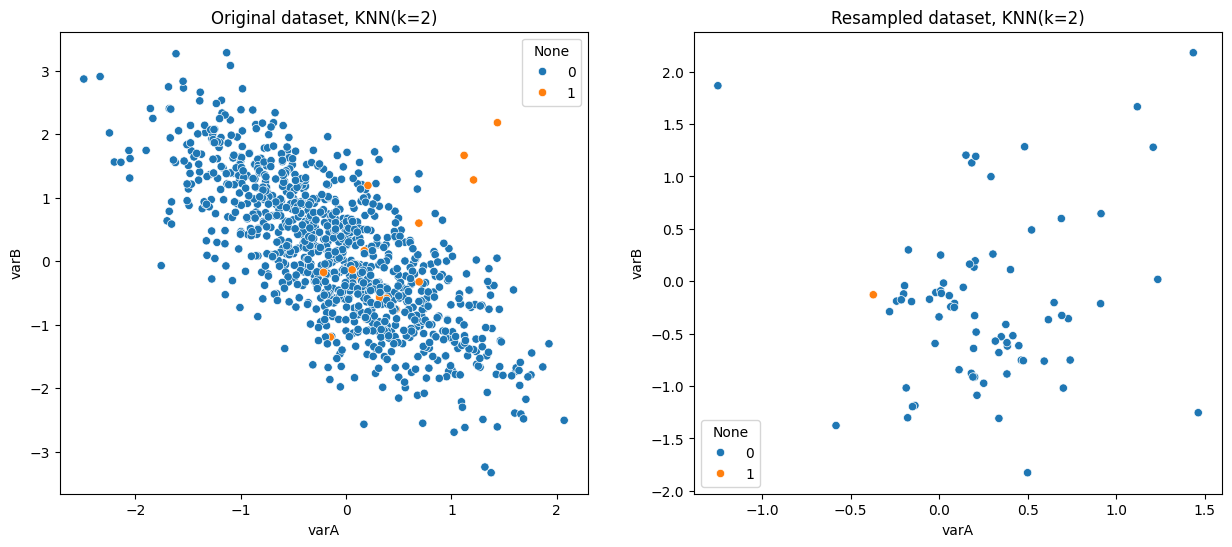

In [ ]:
#the hue for the resampled data uses the y instead of the y-resampled
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.scatterplot(x='varA', y='varB', data=X, hue=y)
plt.title('Original dataset, KNN(k=2)')

plt.subplot(122)
sns.scatterplot(x='varA', y='varB', data=X_resampled, hue=y)
plt.title('Resampled dataset, KNN(k=2)')

# Condensed Nearest Neighbour -- Real Data - Performance Comparison

In [100]:
df = pd.read_csv('../kdd2004.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,target
0,52.0,32.69,0.30,2.5,20.0,1256.8,-0.89,0.33,11.0,-55.0,...,1595.1,-1.64,2.83,-2.0,-50.0,445.2,-0.35,0.26,0.76,-1
1,58.0,33.33,0.00,16.5,9.5,608.1,0.50,0.07,20.5,-52.5,...,762.9,0.29,0.82,-3.0,-35.0,140.3,1.16,0.39,0.73,-1
2,77.0,27.27,-0.91,6.0,58.5,1623.6,-1.40,0.02,-6.5,-48.0,...,1491.8,0.32,-1.29,0.0,-34.0,658.2,-0.76,0.26,0.24,-1
3,41.0,27.91,-0.35,3.0,46.0,1921.6,-1.36,-0.47,-32.0,-51.5,...,2047.7,-0.98,1.53,0.0,-49.0,554.2,-0.83,0.39,0.73,-1
4,50.0,28.00,-1.32,-9.0,12.0,464.8,0.88,0.19,8.0,-51.5,...,479.5,0.68,-0.59,2.0,-36.0,-6.9,2.02,0.14,-0.23,-1


In [101]:
df.target.value_counts(normalize=True)

target
-1    0.991108
 1    0.008892
Name: proportion, dtype: float64

In [102]:
df.target = df.target.map({-1:0, 1:1})
df.target.value_counts(normalize=True)

target
0    0.991108
1    0.008892
Name: proportion, dtype: float64

In [103]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [106]:
X = df.drop('target', axis=1)
X.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60',
       '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72',
       '73'],
      dtype='object')

In [107]:
y=df.target
y.unique()

array([0, 1])

In [108]:
y.nunique()

2

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((102025, 74), (102025,), (43726, 74), (43726,))

In [110]:
from imblearn.under_sampling import CondensedNearestNeighbour

In [111]:
?CondensedNearestNeighbour

Init signature:
CondensedNearestNeighbour(
    *,
    sampling_strategy='auto',
    random_state=None,
    n_neighbors=None,
    n_seeds_S=1,
    n_jobs=None,
)
Docstring:     
Undersample based on the condensed nearest neighbour method.

Read more in the :ref:`User Guide <condensed_nearest_neighbors>`.

Parameters
----------
sampling_strategy : str, list or callable
    Sampling information to sample the data set.

    - When ``str``, specify the class targeted by the resampling. Note the
      the number of samples will not be equal in each. Possible choices
      are:

        ``'majority'``: resample only the majority class;

        ``'not minority'``: resample all classes but the minority class;

        ``'not majority'``: resample all classes but the majority class;

        ``'all'``: resample all classes;

        ``'auto'``: equivalent to ``'not minority'``.

    - When ``list``, the list contains the classes targeted by the
      resampling.

    - When callable, function t

In [112]:
cnn = CondensedNearestNeighbour(sampling_strategy='auto',
                                random_state=0,
                                n_neighbors=1,
                                n_jobs=-1)

X_resampled, y_resampled = cnn.fit_resample(X_train, y_train)

In [113]:
y_train.value_counts(normalize=True)

target
0    0.991267
1    0.008733
Name: proportion, dtype: float64

In [114]:
y_resampled.value_counts(normalize=True)

target
0    0.823039
1    0.176961
Name: proportion, dtype: float64

# Plotting data

Text(0.5, 1.0, 'Condensed Nearest Neighbour, Resampled Data')

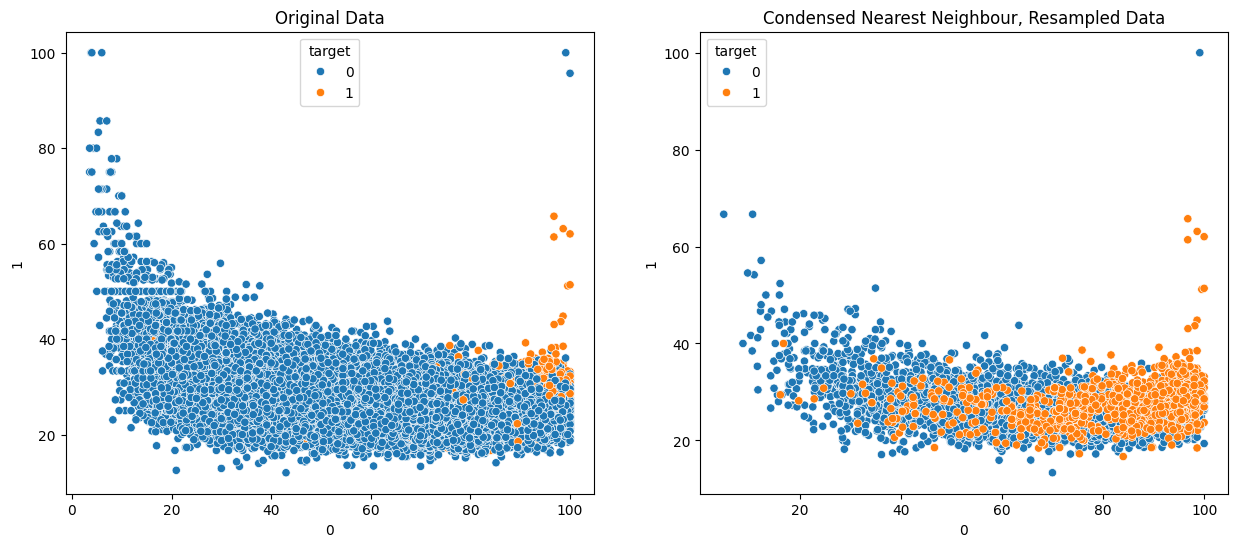

In [115]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.scatterplot(data=X_train, x='0', y='1', hue=y_train)
plt.title('Original Data')

plt.subplot(122)
sns.scatterplot(data=X_resampled, x='0', y='1', hue=y_resampled)
plt.title('Condensed Nearest Neighbour, Resampled Data')

In [116]:
X_train.shape, X_resampled.shape

((102025, 74), (5035, 74))

Text(0.5, 1.0, 'Resampled Data')

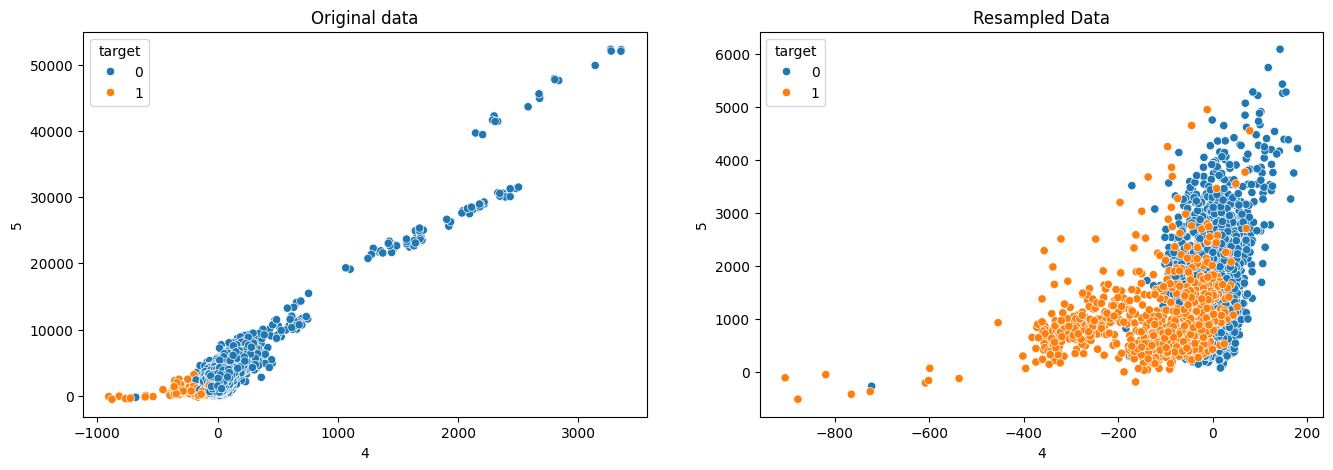

In [117]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.scatterplot(x='4', y='5', data=X_train, hue=y_train)
plt.title('Original data')

plt.subplot(122)
sns.scatterplot(x='4', y='5', data=X_resampled, hue=y_resampled)
plt.title('Resampled Data')


# Machine learning performance comparison

In [118]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
from sklearn.metrics import roc_auc_score

In [120]:
def run_randomForests(X_train, X_test, y_train, y_test):

    rf = RandomForestClassifier(n_estimators=200, random_state=0, max_depth=4, n_jobs=-1)
    rf.fit(X_train, y_train)
           
    print('Train Set')
    pred = rf.predict_proba(X_train)[:,1]
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pred)))

    print('Test Set')
    pred = rf.predict_proba(X_test)[:,1]
    print('Random Forests roc_auc: {}'.format(roc_auc_score(y_test, pred)))


In [121]:
run_randomForests(X_train, X_test, y_train, y_test)

Train Set
Random Forests roc-auc: 0.9744228285141
Test Set
Random Forests roc_auc: 0.9724479987324028


In [122]:
#Evaluating the performance using the undersampled data
run_randomForests(X_resampled, X_test, y_resampled, y_test)

Train Set
Random Forests roc-auc: 0.9798572923572924
Test Set
Random Forests roc_auc: 0.9811112051549715
